# Brain Tumor MRI — Exploratory Data Analysis

This notebook explores the Brain Tumor MRI dataset (glioma, meningioma, pituitary, notumor) across the train and test splits: class balance, image properties, pixel statistics, data quality (corrupt files, duplicates, train/test leakage), and label sanity checks.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np
import pandas as pd

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## 1. Setup and imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

sns.set_style("whitegrid")

DATA_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

## 2. Build a file index

In [3]:
def build_index(root_dir, split_name):
    records = []
    for cls in CLASSES:
        cls_dir = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_dir):
            records.append({"filepath": os.path.join(cls_dir, fname), "class": cls, "split": split_name})
    return pd.DataFrame(records)

df_train = build_index(TRAIN_DIR, "train")
df_test = build_index(TEST_DIR, "test")
df = pd.concat([df_train, df_test], ignore_index=True)

print(df.shape)
df.head()

(7200, 3)


,filepath,class,split
0,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train
1,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train
2,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train
3,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train
4,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train


**Summary:** Combined a single dataframe (`df`) listing every image's filepath, class label, and split (`train`/`test`), giving a common structure to drive the rest of the analysis.

## 3. Class distribution (train vs. test)

/tmp/ipykernel_24/683804446.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x="class", order=CLASSES, ax=axes[0], palette="viridis")
/tmp/ipykernel_24/683804446.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_test, x="class", order=CLASSES, ax=axes[1], palette="viridis")


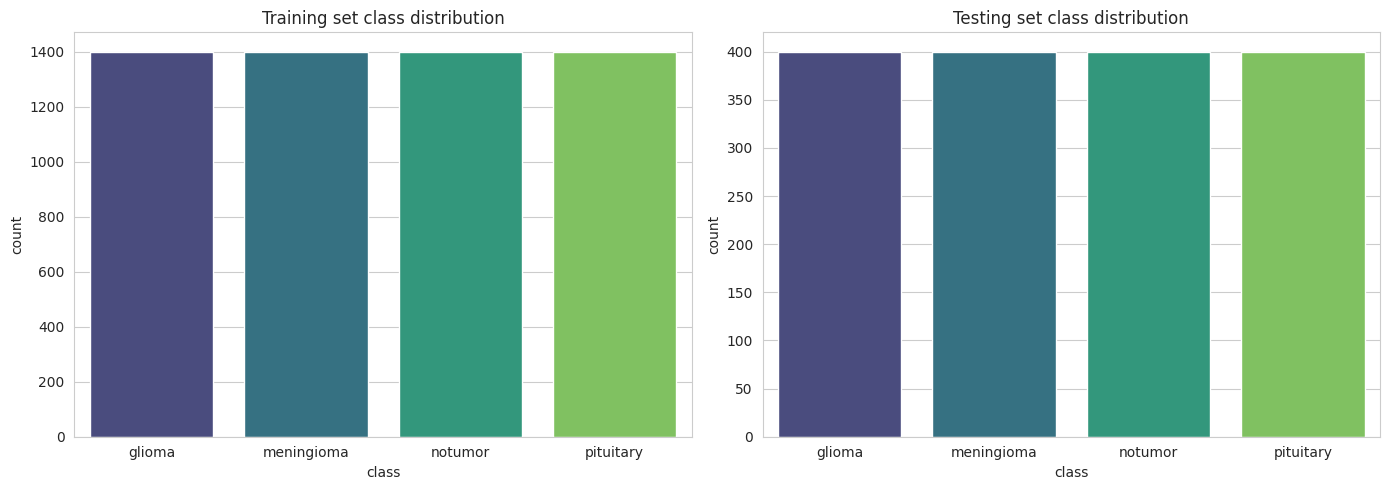

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df_train, x="class", order=CLASSES, ax=axes[0], palette="viridis")
axes[0].set_title("Training set class distribution")
sns.countplot(data=df_test, x="class", order=CLASSES, ax=axes[1], palette="viridis")
axes[1].set_title("Testing set class distribution")
plt.tight_layout()
plt.show()

In [5]:
summary = df.groupby(["split", "class"]).size().unstack(fill_value=0)
summary["total"] = summary.sum(axis=1)
summary.loc["total"] = summary.sum()
print(summary)

class  glioma  meningioma  notumor  pituitary  total
split                                               
test      400         400      400        400   1600
train    1400        1400     1400       1400   5600
total    1800        1800     1800       1800   7200


### 3a. Quantifying class imbalance

In [6]:
imbalance = summary.drop(index="total").drop(columns="total").copy()

for split_name, split_df in [("train", df_train), ("test", df_test)]:
    counts = split_df["class"].value_counts().reindex(CLASSES)
    proportions = (counts / counts.sum() * 100).round(2)
    imbalance_ratio = round(counts.max() / counts.min(), 2)
    print(f"--- {split_name} ---")
    print("Counts:\n", counts.to_string())
    print("Proportions (%):\n", proportions.to_string())
    print(f"Majority:minority imbalance ratio: {imbalance_ratio}:1 "
          f"({counts.idxmax()} vs {counts.idxmin()})\n")


--- train ---
Counts:
 class
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Proportions (%):
 class
glioma        25.0
meningioma    25.0
notumor       25.0
pituitary     25.0
Majority:minority imbalance ratio: 1.0:1 (glioma vs glioma)

--- test ---
Counts:
 class
glioma        400
meningioma    400
notumor       400
pituitary     400
Proportions (%):
 class
glioma        25.0
meningioma    25.0
notumor       25.0
pituitary     25.0
Majority:minority imbalance ratio: 1.0:1 (glioma vs glioma)



## 4. Sample images per class

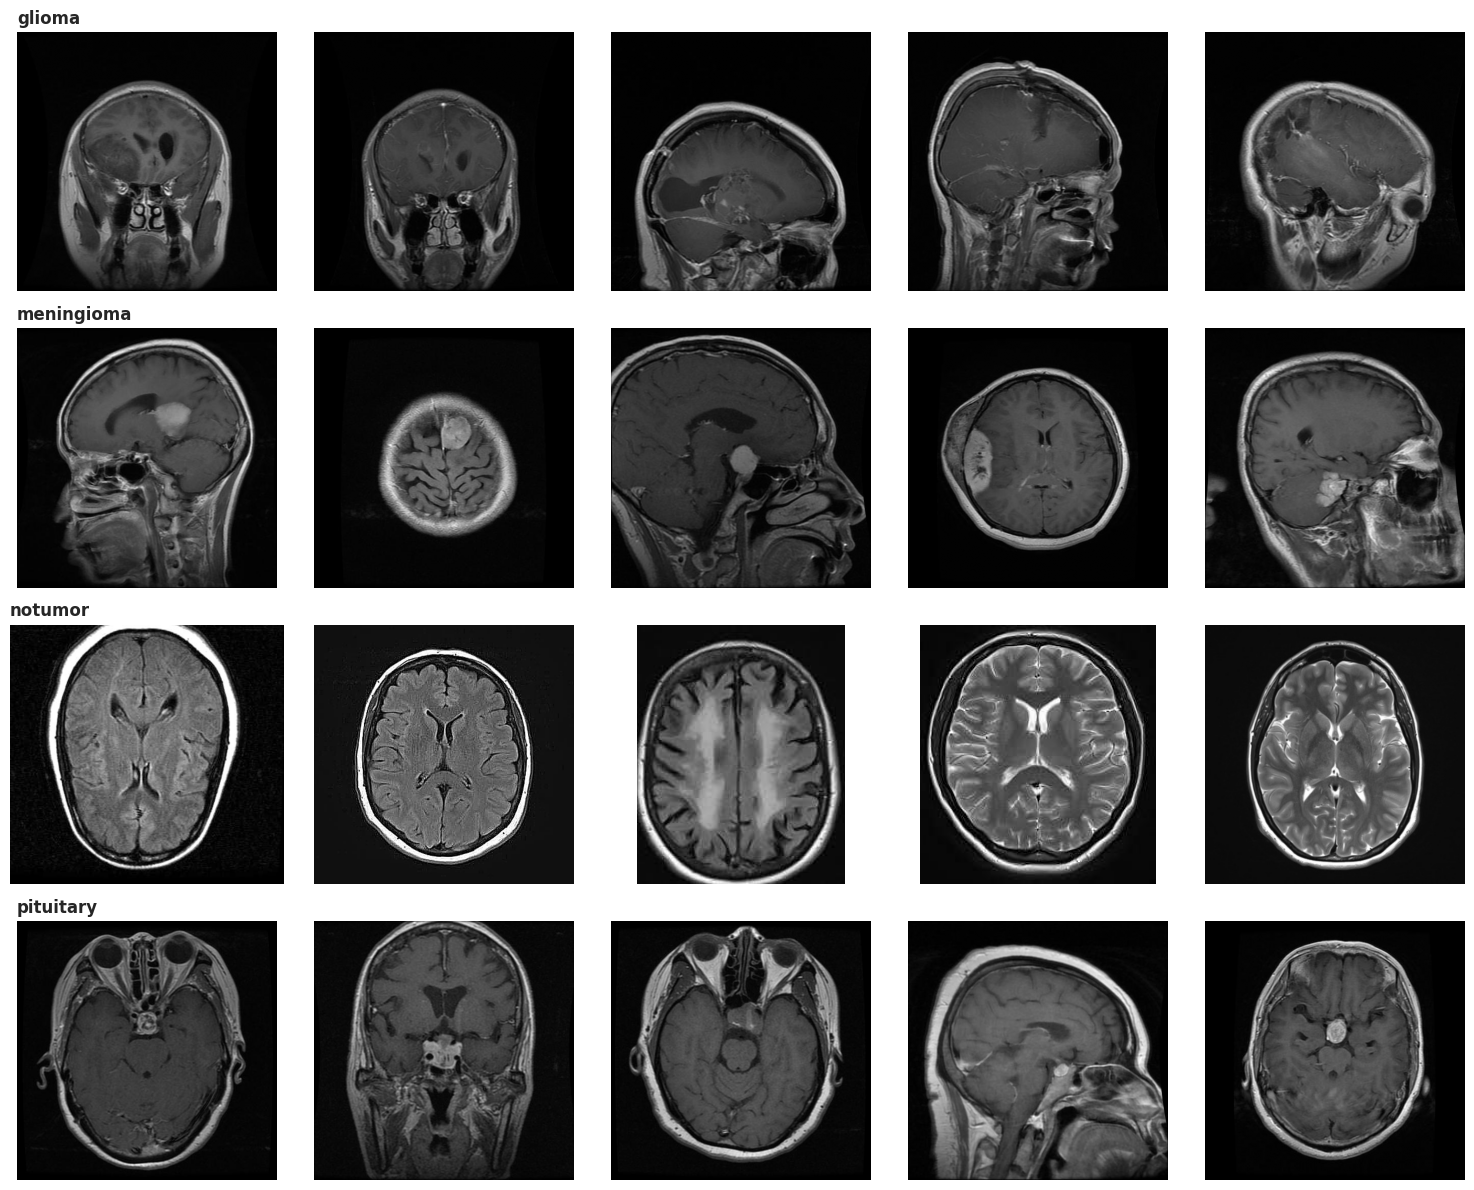

In [7]:
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(15, 12))
for i, cls in enumerate(CLASSES):
    samples = df_train[df_train["class"] == cls].sample(5, random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["filepath"])
        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].axis("off")
    axes[i, 0].set_title(cls, loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Image dimensions and color mode

In [8]:
def get_image_props(filepath):
    with Image.open(filepath) as img:
        w, h = img.size
        mode = img.mode
    return w, h, mode

props = df["filepath"].apply(get_image_props)
df["width"] = props.apply(lambda x: x[0])
df["height"] = props.apply(lambda x: x[1])
df["mode"] = props.apply(lambda x: x[2])

print(df[["width", "height"]].describe())
print(df["mode"].value_counts())

             width       height
count  7200.000000  7200.000000
mean    453.302917   456.899167
std     130.048964   124.402496
min     150.000000   167.000000
25%     442.000000   449.000000
50%     512.000000   512.000000
75%     512.000000   512.000000
max    1375.000000  1446.000000
mode
RGB     4129
L       3067
RGBA       3
P          1
Name: count, dtype: int64


## 6. Pixel intensity and contrast by class

/tmp/ipykernel_24/3141564448.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="mean_intensity", order=CLASSES, palette="Set2")


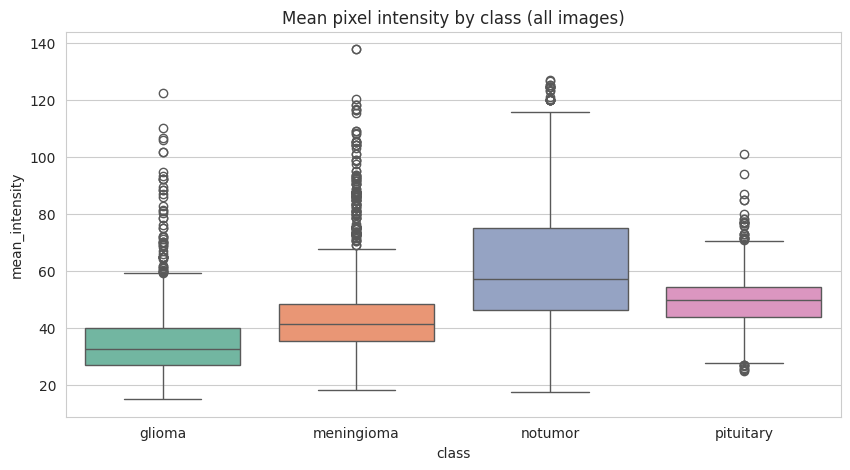

/tmp/ipykernel_24/3141564448.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="std_intensity", order=CLASSES, palette="Set2")


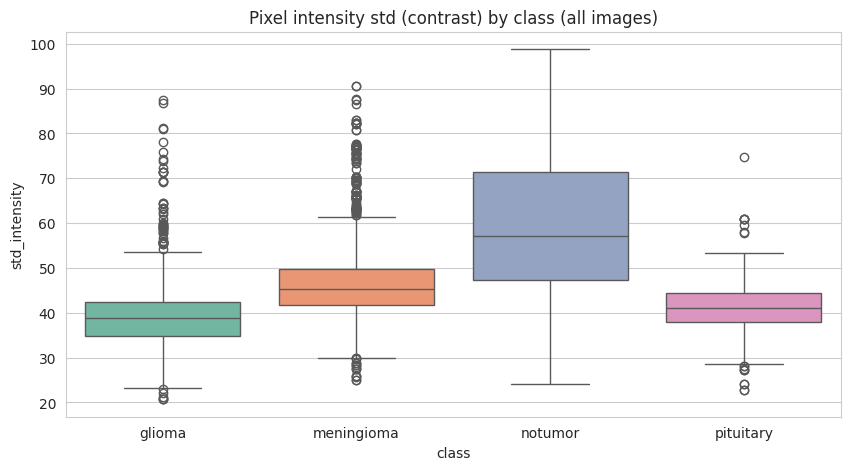

In [9]:
def mean_pixel_intensity(filepath, size=(128, 128)):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size)
    return img.mean(), img.std()

intensity_results = df["filepath"].apply(lambda fp: pd.Series(mean_pixel_intensity(fp)))
df[["mean_intensity", "std_intensity"]] = intensity_results

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="class", y="mean_intensity", order=CLASSES, palette="Set2")
plt.title("Mean pixel intensity by class (all images)")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="class", y="std_intensity", order=CLASSES, palette="Set2")
plt.title("Pixel intensity std (contrast) by class (all images)")
plt.show()

## 7. Average image per class

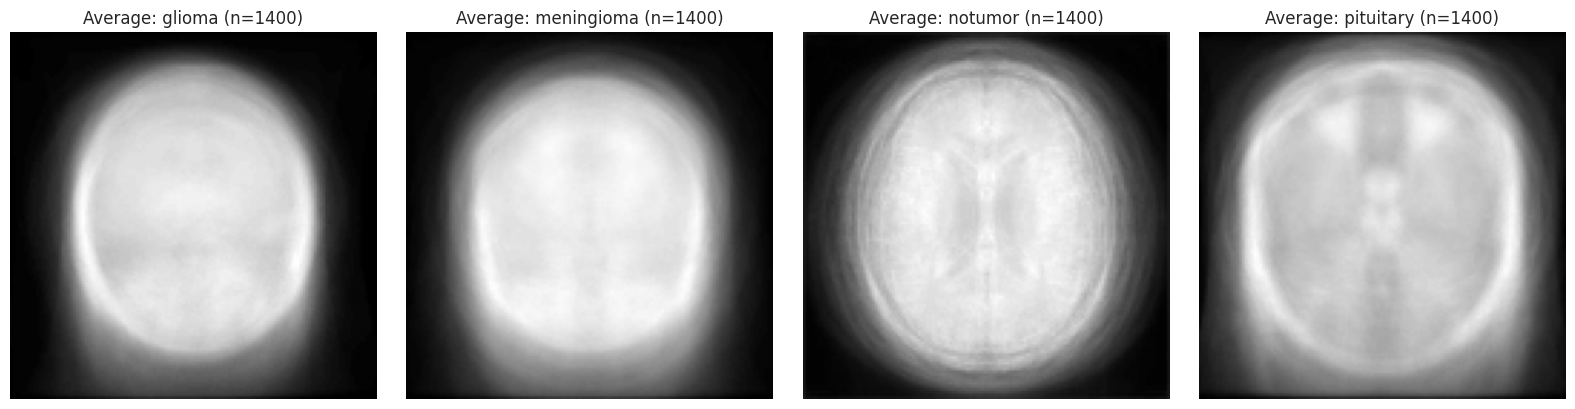

In [10]:
def average_image(filepaths, size=(128, 128)):
    acc = np.zeros(size, dtype=np.float64)
    for fp in filepaths:
        img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, size).astype(np.float64)
        acc += img
    return (acc / len(filepaths)).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(CLASSES):
    files = df_train[df_train["class"] == cls]["filepath"].tolist()  # ALL images, no sampling
    axes[i].imshow(average_image(files), cmap="gray")
    axes[i].set_title(f"Average: {cls} (n={len(files)})")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 8. Data quality: corrupt files and duplicates

In [11]:
import hashlib

corrupt_files = []
for fp in df["filepath"]:
    try:
        Image.open(fp).verify()
    except Exception:
        corrupt_files.append(fp)
print("Corrupt files:", len(corrupt_files))

def file_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["hash"] = df["filepath"].apply(file_hash)
print("Duplicate images:", df.duplicated("hash").sum())

Corrupt files: 0
Duplicate images: 187


## 9. Train/test leakage check

In [12]:
train_hashes = set(df[df["split"] == "train"]["hash"])
test_hashes = set(df[df["split"] == "test"]["hash"])
print("Images in both train and test:", len(train_hashes & test_hashes))

Images in both train and test: 0


## 10. Missing values and label sanity check

In [13]:
# 1. Confirm every row has non-null required fields
missing_summary = df[["filepath", "class", "split"]].isnull().sum()
print("Missing values per column:\n", missing_summary.to_string())

# 2. Confirm every label is one of the expected classes (no stray/misspelled folder names)
unexpected_classes = set(df["class"].unique()) - set(CLASSES)
print("\nUnexpected class labels found:", unexpected_classes if unexpected_classes else "None")

# 3. Confirm every split is one of the expected values
unexpected_splits = set(df["split"].unique()) - {"train", "test"}
print("Unexpected split labels found:", unexpected_splits if unexpected_splits else "None")

# 4. Confirm every filepath on record actually exists on disk
missing_files = df[~df["filepath"].apply(os.path.exists)]
print(f"\nRecords pointing to a non-existent file: {len(missing_files)}")

# 5. Confirm no empty (0-byte) files, which would load without a Python exception but contain no data
zero_byte_files = df[df["filepath"].apply(lambda fp: os.path.getsize(fp) == 0)]
print(f"Zero-byte files: {len(zero_byte_files)}")

# 6. Confirm every class folder contributed at least one sample to both splits
class_split_coverage = df.groupby(["class", "split"]).size().unstack(fill_value=0)
print("\nClass x split coverage (should have no zeros):\n", class_split_coverage)


Missing values per column:
 filepath    0
class       0
split       0

Unexpected class labels found: None
Unexpected split labels found: None

Records pointing to a non-existent file: 0
Zero-byte files: 0

Class x split coverage (should have no zeros):
 split       test  train
class                  
glioma       400   1400
meningioma   400   1400
notumor      400   1400
pituitary    400   1400


## 11. File size distribution

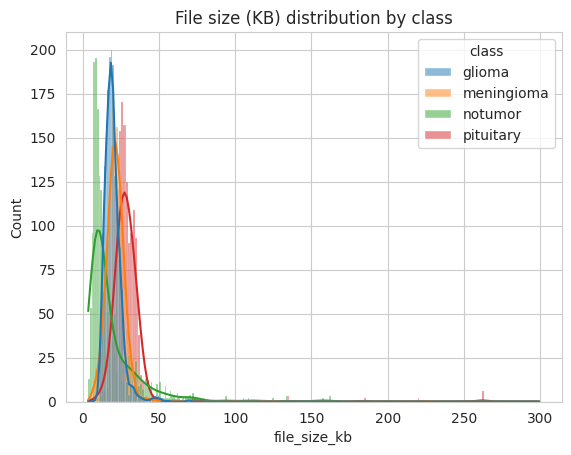

             count       mean        std        min        25%        50%  \
class                                                                       
glioma      1800.0  19.706546   5.522643   7.991211  16.279785  18.937012   
meningioma  1800.0  21.863453   8.757336   4.803711  17.932373  21.337891   
notumor     1800.0  19.640281  21.688731   3.594727   8.640625  12.101562   
pituitary   1800.0  29.853607  19.137893  10.371094  24.441162  27.657227   

                  75%         max  
class                              
glioma      22.018555   70.210938  
meningioma  24.992188  227.586914  
notumor     22.024902  299.308594  
pituitary   32.119141  262.511719  


In [14]:
df["file_size_kb"] = df["filepath"].apply(lambda fp: os.path.getsize(fp) / 1024)
sns.histplot(data=df, x="file_size_kb", hue="class", kde=True)
plt.title("File size (KB) distribution by class")
plt.show()

print(df.groupby("class")["file_size_kb"].describe())

## Overall EDA conclusions

- **Class balance:** Perfectly balanced. Every class has exactly 1,400 images in train and 400 in test (1,800 total each), giving an imbalance ratio of 1.0:1 in both splits. No class weighting, oversampling, or augmentation for balance is needed.
- **Image consistency:** Not consistent, resizing is required. Dimensions range from 150×167 up to 1375×1446 (mean ≈453×457, median 512×512), and color mode is mixed: 4,129 images are RGB, 3,067 are grayscale (L), plus a handful of RGBA/palette images. So the pipeline needs two fixes, not just one: (1) resize everything to a single target (512×512 or 224×224 depending on your model architecture — 224×224 is standard if you're using a pretrained CNN backbone), and (2) convert all images to a single consistent channel format (typically grayscale, since MRI scans carry no real color information — the RGB ones are likely just grayscale duplicated across 3 channels, but have to confirm that before collapsing them.
- **Data quality:** Clean on the leakage front, one thing to fix on duplicates. Corrupt files: 0. Train/test leakage: 0 images shared between splits — good, your test metrics will be trustworthy. However, duplicate detection found 187 duplicate images overall (by exact file hash), and since none of those are cross-split, all 187 are duplicates within the same split. Before training, we have to dedupe these — leaving exact copies in the training set gives them extra weight and can subtly bias the model, and if any land in a train/val split later, an identical image could appear in both.
- **Label integrity:**Fully confirmed clean. No null filepaths/classes/splits, no unexpected class or split labels, no missing (non-existent) files, no zero-byte files, and every class is represented in both splits at the expected counts (1,400/400). No cleanup needed here.
- **Next steps:** Resize all images to one target resolution (e.g. 224×224) and standardize to a single channel mode (likely grayscale).
Normalize pixel values (0–1 or mean/std standardization) — file-size and intensity stats vary a fair amount by class (e.g. notumor file sizes range from 3.6 KB to 299 KB), so scale before feeding to a model.
Deduplicate the 187 duplicate images (drop repeats, keep one copy each).
Create a stratified train/val split out of the training folder (test stays untouched) — since classes are balanced, a straightforward stratified split (e.g. 90/10) works fine.
No class-imbalance handling needed — skip class weighting/oversampling since the ratio is 1.0:1..